# SHAP Analysis — 05

**Objetivo:** explicar las predicciones del XGBoost de la fase 5 sobre
validación usando SHAP (fase 7). Cada valor SHAP es la contribución de una
feature al `log_precio_usd` predicho: `base + Σ contribuciones ≈ predicción`
(propiedad aditiva). Para interpretar en USD, `exp(contribución)` es el factor
multiplicativo que esa feature aplica sobre el precio.

**Entrada:** `data/processed/propiedades_argenprop_curado.csv`
**Salida:** `reports/figures/` (beeswarm e importancia global, PNG)

## Configuración

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Bootstrap para importar `real_estate` (layout src/) sin instalar el paquete.
SRC_DIR = Path.cwd().parent / "src"
if not SRC_DIR.exists():
    SRC_DIR = Path.cwd() / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from real_estate.explainability import (  # noqa: E402
    calcular_shap,
    grafico_barras,
    grafico_resumen,
    guardar_figuras,
)
from real_estate.features import pipeline as pl  # noqa: E402
from real_estate.features import transformations as tr  # noqa: E402
from real_estate.models import entrenamiento as en  # noqa: E402

RUTA_CURADO = Path("../data/processed/propiedades_argenprop_curado.csv")
RUTA_FIGURAS = Path("../reports/figures")

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

## 1. Carga y split train / val / test

Igual que en el notebook 04: preprocesamiento ajustado **solo sobre train** y
reaplicado a val/test (sin fuga). El análisis SHAP se hace sobre validación.

In [2]:
df_curado = pd.read_csv(RUTA_CURADO, low_memory=False)
print(f"Curado: {df_curado.shape[0]:,} filas x {df_curado.shape[1]} columnas")

matriz = tr.crear_target_log(tr.seleccionar_columnas(df_curado))
train, val, test = pl.dividir_train_val_test(matriz, random_state=42)

print(f"Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}")

Curado: 2,005 filas x 32 columnas
Descartadas 6 filas con precio inválido (< 1,000 USD).
Train: 1,599 | Val: 200 | Test: 200


## 2. Preprocesamiento ajustado solo sobre train

In [3]:
ajustes = en.ajustar_preprocesamiento(train)

train_proc = en.aplicar_preprocesamiento(train, ajustes)
val_proc = en.aplicar_preprocesamiento(val, ajustes)
test_proc = en.aplicar_preprocesamiento(test, ajustes)

print(
    f"NaN totales tras preprocesar: train {int(train_proc.isna().sum().sum())} | "
    f"val {int(val_proc.isna().sum().sum())} | test {int(test_proc.isna().sum().sum())}"
)

NaN totales tras preprocesar: train 0 | val 0 | test 0


## 3. Features y target

In [4]:
X_train, y_train = en.separar_features_target(train_proc)
X_val, y_val = en.separar_features_target(val_proc)

print(f"Features ({X_train.shape[1]}): {list(X_train.columns)}")
print("Target: log_precio_usd")

Features (14): ['superficie_cubierta', 'ambientes', 'dormitorios', 'banos', 'antiguedad', 'expensas_usd', 'expensas_informado', 'superficie_cubierta_informado', 'ambientes_informado', 'dormitorios_informado', 'banos_informado', 'antiguedad_informado', 'barrio_ordinal', 'tipo_propiedad_ordinal']
Target: log_precio_usd


## 4. Entrenamiento del XGBoost

Se reentrena el modelo sobre train (mismos hiperparámetros que en el notebook
04) para tenerlo disponible en memoria con su codificación exacta.

In [5]:
xgb = en.entrenar_xgboost(X_train, y_train)

met_xgb_val = en.calcular_metricas(y_val, xgb.predict(X_val))
en.mostrar_metricas("xgboost (val)", met_xgb_val)

  xgboost (val) | RMSE log: 0.2718 | RMSE USD:      112,963 | R²: 0.8205


## 5. SHAP sobre validación

`calcular_shap` ajusta un `shap.TreeExplainer` sobre el modelo ya entrenado y
explica la matriz `X_val`. Devuelve un `ExplicacionSHAP` con:
- `valores`: matriz (n_val, n_features) de contribuciones al log precio;
- `base`: valor esperado del modelo (log precio de referencia);
- `nombres`: features en el orden de las columnas.

In [6]:
explicacion = calcular_shap(xgb, X_val)

print(f"Valores SHAP: {explicacion.valores.shape}")
print(
    f"Base (valor esperado): {explicacion.base:.4f}  ->  exp = {np.exp(explicacion.base):,.0f} USD"
)
print(f"Features ({len(explicacion.nombres)}): {list(explicacion.nombres)}")

Valores SHAP: (200, 14)
Base (valor esperado): 11.9718  ->  exp = 158,234 USD
Features (14): ['superficie_cubierta', 'ambientes', 'dormitorios', 'banos', 'antiguedad', 'expensas_usd', 'expensas_informado', 'superficie_cubierta_informado', 'ambientes_informado', 'dormitorios_informado', 'banos_informado', 'antiguedad_informado', 'barrio_ordinal', 'tipo_propiedad_ordinal']


## 6. Propiedad aditiva: base + Σ contribuciones ≈ predicción

Es la verificación central de SHAP: si no se cumple, los valores no son
interpretables. La reconstrucción debe coincidir con `modelo.predict(X_val)`.

In [7]:
reconstruida = explicacion.base + explicacion.valores.sum(axis=1)
predicha = xgb.predict(X_val)

error_max = np.max(np.abs(reconstruida - predicha))
print(f"Error máximo de reconstrucción: {error_max:.2e}")
print("Cumple base + Σ SHAP ≈ predicción:", np.allclose(reconstruida, predicha, atol=1e-3))

Error máximo de reconstrucción: 8.59e-06
Cumple base + Σ SHAP ≈ predicción: True


## 7. Importancia global (media |SHAP|)

Mide cuánto mueve cada feature, en promedio, el log precio predicho (en valor
absoluto). Es más fiel que `feature_importances_` de XGBoost porque refleja la
magnitud real del efecto, no la frecuencia de splits.

In [8]:
importancia = explicacion.importancia_global()
print(importancia.round(4).to_string())

superficie_cubierta              0.2966
barrio_ordinal                   0.1386
expensas_usd                     0.0698
antiguedad_informado             0.0643
tipo_propiedad_ordinal           0.0613
antiguedad                       0.0518
ambientes                        0.0433
banos_informado                  0.0362
banos                            0.0296
superficie_cubierta_informado    0.0150
expensas_informado               0.0082
dormitorios                      0.0038
ambientes_informado              0.0036
dormitorios_informado            0.0030


## 8. Gráficos: beeswarm e importancia

El beeswarm (resumen) muestra, por feature y en orden de importancia, la
distribución de contribuciones; el color indica el valor de la feature (rojo
alto, azul bajo). La barra resume la media |SHAP|.

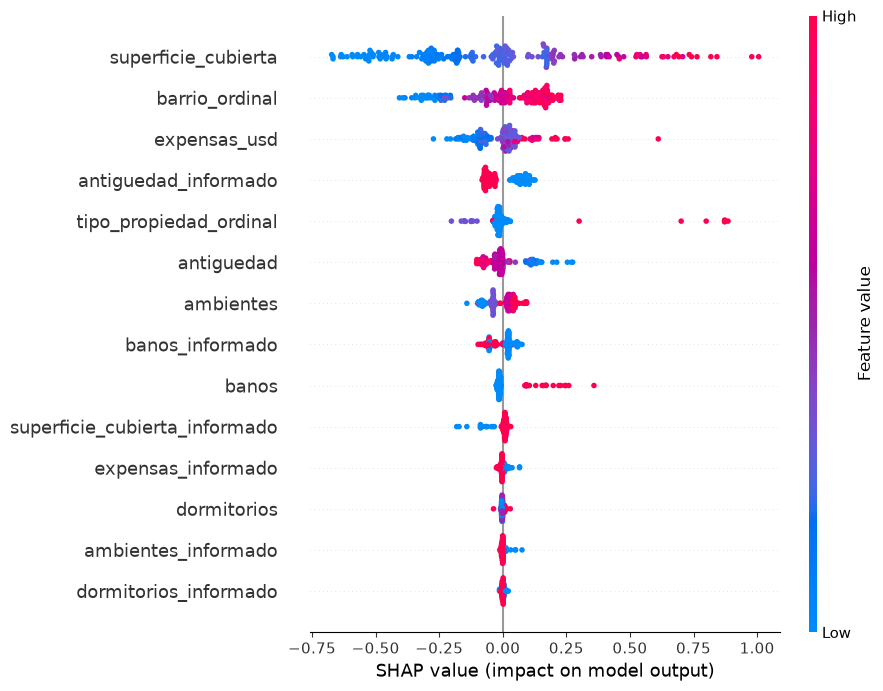

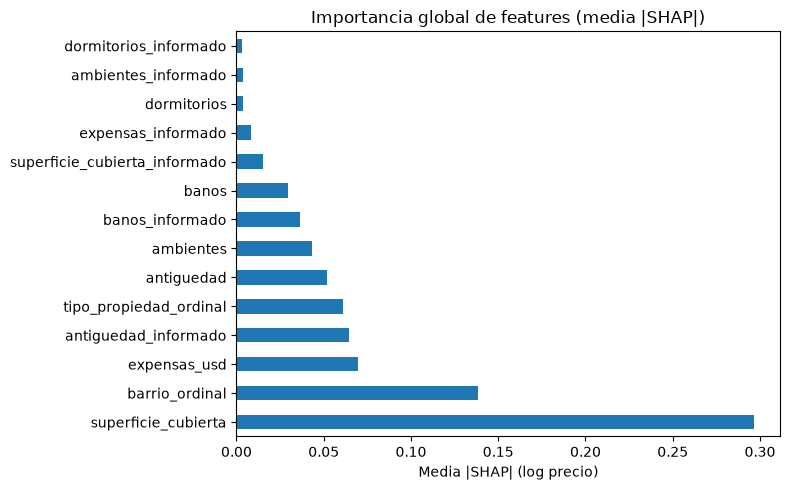

In [9]:
fig_resumen = grafico_resumen(explicacion, X_val)
plt.show()

fig_barras = grafico_barras(explicacion)
plt.show()

## 9. Interpretación en USD

Como el target es `log_precio_usd`, cada contribución se traduce a un factor
multiplicativo: `exp(contribución)`. Un SHAP de `+0.35` en `superficie_cubierta`
significa `exp(0.35) ≈ 1.42`, es decir, esa feature empuja el precio **un 42%
arriba** respecto del valor base para esa observación.

Descomponemos la predicción de la primera observación de validación.

In [10]:
i = 0
contribuciones = pd.Series(explicacion.valores[i], index=explicacion.nombres)
factor_usd = np.exp(contribuciones)

pred_log = explicacion.base + contribuciones.sum()
print(f"Predicción obs {i}: log = {pred_log:.4f}  ->  {np.exp(pred_log):,.0f} USD")

tabla = pd.DataFrame({"shap (log)": contribuciones, "factor USD": factor_usd})
print("\nFactores que MÁS suben el precio:")
print(tabla.sort_values("shap (log)", ascending=False).head(5).round(4).to_string())
print("\nFactores que MÁS bajan el precio:")
print(tabla.sort_values("shap (log)").head(5).round(4).to_string())

Predicción obs 0: log = 11.5434  ->  103,093 USD

Factores que MÁS suben el precio:
                               shap (log)  factor USD
ambientes                          0.0278      1.0282
banos_informado                    0.0242      1.0245
superficie_cubierta                0.0180      1.0181
superficie_cubierta_informado      0.0097      1.0097
dormitorios_informado             -0.0010      0.9990

Factores que MÁS bajan el precio:
                        shap (log)  factor USD
barrio_ordinal             -0.2515      0.7777
expensas_usd               -0.0869      0.9168
antiguedad_informado       -0.0666      0.9356
antiguedad                 -0.0585      0.9432
tipo_propiedad_ordinal     -0.0227      0.9775


## 10. Guardar figuras

Se persisten como PNG en `reports/figures/` (carpeta gitignored: se regeneran
con este notebook; solo se versiona `.gitkeep`).

In [11]:
rutas = guardar_figuras(
    {"shap_resumen": fig_resumen, "shap_importancia": fig_barras},
    RUTA_FIGURAS,
)
for ruta in rutas:
    print(f"Guardado: {ruta} ({ruta.stat().st_size:,} bytes)")

Guardado: ..\reports\figures\shap_resumen.png (131,622 bytes)
Guardado: ..\reports\figures\shap_importancia.png (60,931 bytes)


## 11. Conclusiones

In [12]:
print("SHAP (fase 7) sobre validación:")
print(
    f"  base = exp({explicacion.base:.4f}) = {np.exp(explicacion.base):,.0f} USD (precio de referencia)"
)
print(f"  propiedad aditiva verificada (error máx {error_max:.2e})")
print(f"  top-3 features por media |SHAP|: {list(importancia.index[:3])}")
print("  interpretación: cada SHAP es un factor multiplicativo en USD vía exp()")
print(f"  figuras guardadas en {RUTA_FIGURAS}")
print(
    "\nSiguiente: el pipeline queda cerrado con entrenamiento (5), tracking (6) y explicabilidad (7)."
)

SHAP (fase 7) sobre validación:
  base = exp(11.9718) = 158,234 USD (precio de referencia)
  propiedad aditiva verificada (error máx 8.59e-06)
  top-3 features por media |SHAP|: ['superficie_cubierta', 'barrio_ordinal', 'expensas_usd']
  interpretación: cada SHAP es un factor multiplicativo en USD vía exp()
  figuras guardadas en ..\reports\figures

Siguiente: el pipeline queda cerrado con entrenamiento (5), tracking (6) y explicabilidad (7).
